In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,5)

In [3]:
#Load the data
path = "../data/"

In [4]:
orders = pd.read_csv(path + "olist_orders_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")

In [8]:
orders.shape

(99441, 8)

In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
delivered = orders[orders['order_status'] == "delivered"].copy()

In [9]:
delivered.shape

(96478, 8)

In [10]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [11]:
# Aggregrating payments per order
payment_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()

In [12]:
# Joining delivery orders with payments
rfm_base = delivered.merge(payment_agg,on="order_id",how="left")

In [13]:
# Join with customers to get unique customer id

* In Olist, every time a customer places a new order they sometimes get a new customer_id.
  But their customer_unique_id stays the same forever — it's their true identity.

In [14]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [15]:
rfm_base = rfm_base.merge(customers[['customer_id','customer_unique_id']],on="customer_id",how = "left")

In [16]:
rfm_base.shape

(96478, 10)

In [17]:
rfm_base.columns.to_list()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'payment_value',
 'customer_unique_id']

In [18]:
# reference date — day after last order in dataset
reference_date = rfm_base['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

Reference date: 2018-08-30


In [25]:
# Calculate RFM per customer
rfm = rfm_base.groupby('customer_unique_id').agg(
    recency= ('order_purchase_timestamp',lambda x : (reference_date - x.max()).days),
    frequency= ('order_id','count'),
    monetary = ('payment_value','sum')
).reset_index()

In [33]:
rfm.sort_values('recency',ascending=True).head()

,customer_unique_id,recency,frequency,monetary
33812,5c58de6fb80e93396e2f35642666b693,1,1,510.96
32558,58ffbb506c34ffb731c99595589a4ebe,1,1,38.37
20009,36a5c01d940c382346247b3e6c485c2d,1,1,38.36
73840,ca36d819c1759cdb6257fef0bb5d362d,1,1,14.89
4587,0c6d7218d5f3fa14514fd29865269993,1,1,178.25


In [30]:
rfm.shape

(93358, 4)

In [31]:
rfm.describe()

,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,165.197003
std,152.591453,0.209097,226.314012
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.052500
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.557500
max,714.000000,15.000000,13664.080000


* Unique customers → 93,358
* Mean frequency   → 1.03 orders per customer
* 50% frequency    → 1.0 (median is exactly 1!)
* Max frequency    → 15 orders
* Mean recency     → 238 days
* Mean monetary    → R$165
* 75% of customers buy exactly once.

## K-Means Clustering

In [34]:
#Normalize RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency','frequency','monetary']])

In [35]:
rfm_scaled.shape

(93358, 3)

In [37]:
rfm_scaled

array([[-0.82535715, -0.1598294 , -0.1029416 ],
       [-0.80569671, -0.1598294 , -0.60980644],
       [ 1.95987274, -0.1598294 , -0.34897276],
       ...,
       [ 2.16303069, -0.1598294 , -0.23302704],
       [-0.77948278, -0.1598294 , -0.13921883],
       [ 1.61253819, -0.1598294 , -0.41375036]], shape=(93358, 3))

### Elbow Plot

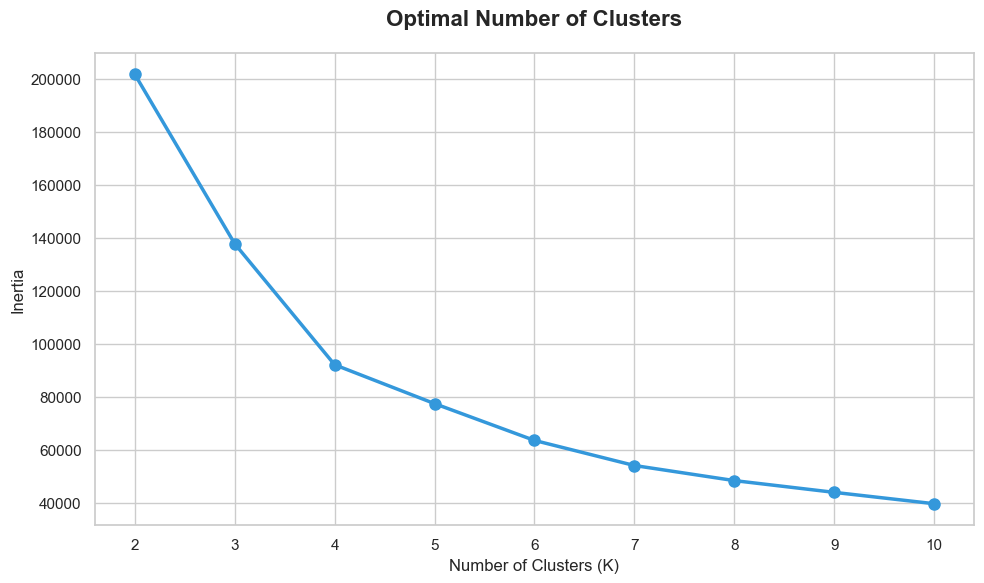

In [40]:
#find optimal number of clusters
inertia = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Chart 11 — Elbow Curve
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(2,11), inertia, marker='o', linewidth=2.5,
        color='#3498db', markersize=8)

ax.set_title('Optimal Number of Clusters',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_xticks(range(2, 11))

plt.tight_layout()
plt.savefig('../charts/chart11_elbow.png', dpi=150)
plt.show()

In [41]:
kmeans = KMeans(n_clusters=4,n_init=10,random_state=42)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

In [43]:
rfm['cluster'].value_counts()

cluster
3    50642
0    37526
1     2772
2     2418
Name: count, dtype: int64

In [45]:
kmeans.cluster_centers_

array([[ 0.97946658, -0.1598294 , -0.14004165],
       [-0.11467315,  5.1695703 ,  0.55004953],
       [ 0.00936581, -0.09838844,  4.40437537],
       [-0.72002264, -0.1598294 , -0.13618332]])

In [47]:
cluster_centers = pd.DataFrame(kmeans.cluster_centers_,columns=['recency','frequency','monetary'])

In [48]:
cluster_centers

,recency,frequency,monetary
0,0.979467,-0.159829,-0.140042
1,-0.114673,5.169570,0.550050
2,0.009366,-0.098388,4.404375
3,-0.720023,-0.159829,-0.136183


<Axes: >

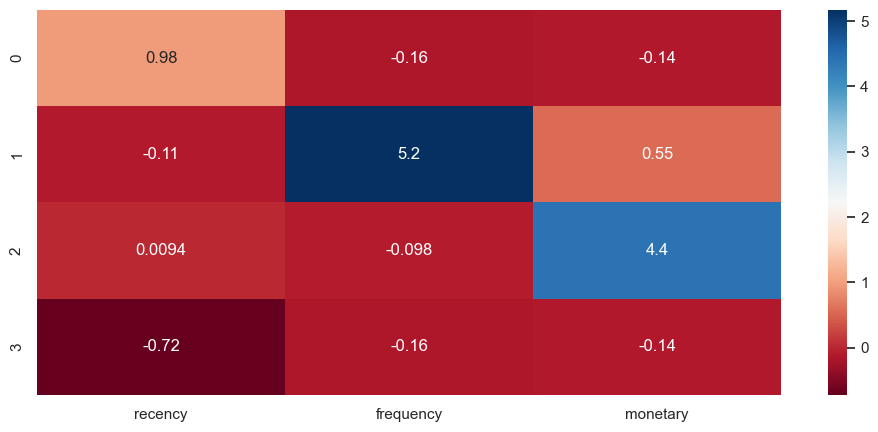

In [51]:
sns.heatmap(cluster_centers,cmap='RdBu',annot=True)

In [52]:
# Cluster 0 -> high receny , low frequency and monetary 
# Cluster 1 -> low receny , high frequency and monetary 
# Cluster 2 -> avg receny , low frequency and high monetary 
# Cluster 3 -> low receny ,frequency and  monetary 

* 0 → Lost Customers    → bought long ago, never returned
* 1 → Champions         → frequent, recent, good spenders
* 2 → High Value        → spent a lot but low frequency
* 3 → New Customers     → very recent but haven't bought again

In [57]:
# Map cluster numbers to business names
segment_names = {
    0: 'Lost Customers',
    1: 'VIP Customers',
    2: 'Sleeping Giants',
    3: 'New Customers'
}

rfm['segment'] = rfm['cluster'].map(segment_names)
print(rfm['segment'].value_counts())

segment
New Customers      50642
Lost Customers     37526
VIP Customers       2772
Sleeping Giants     2418
Name: count, dtype: int64


In [58]:
rfm.head()

,customer_unique_id,recency,frequency,monetary,cluster,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,3,New Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,New Customers
2,0000f46a3911fa3c0805444483337064,537,1,86.22,0,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,0,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,0,Lost Customers


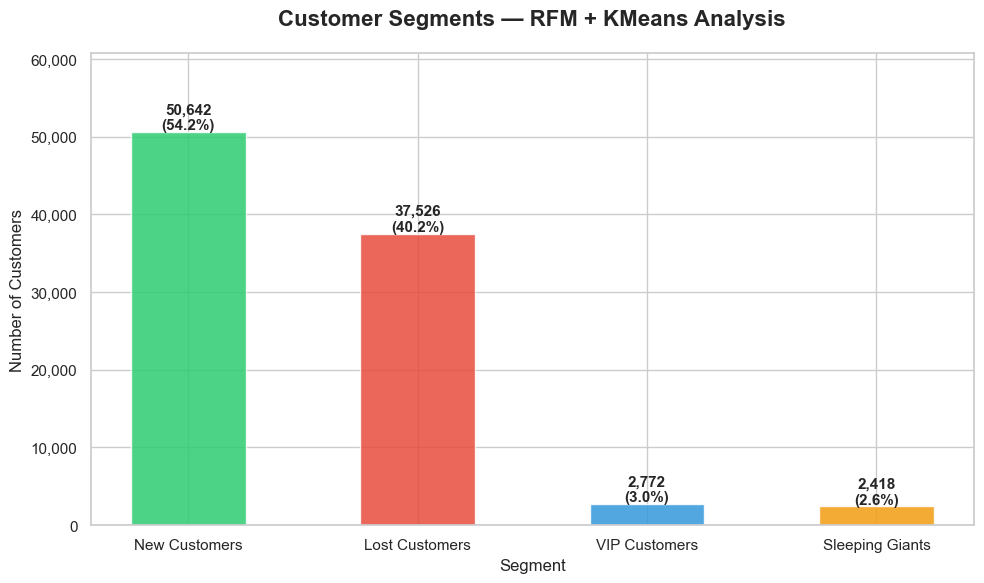

In [59]:
segment_counts = rfm['segment'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

bars = ax.bar(segment_counts.index, segment_counts.values,
              color=colors, alpha=0.85, edgecolor='white', width=0.5)

# Add count + percentage labels
total = len(rfm)
for bar, count in zip(bars, segment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 300,
            f'{count:,}\n({count/total*100:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Customer Segments — RFM + KMeans Analysis',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Segment', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_ylim(0, segment_counts.max() * 1.2)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../charts/chart12_segments.png', dpi=150)
plt.show()

In [60]:
# Calculate average RFM per segment
segment_profile = rfm.groupby('segment').agg(
    recency=('recency', 'mean'),
    frequency=('frequency', 'mean'),
    monetary=('monetary', 'mean')
).reset_index()

print(segment_profile)

           segment     recency  frequency     monetary
0   Lost Customers  387.408517   1.000000   133.457760
1    New Customers  128.074365   1.000000   134.360030
2  Sleeping Giants  239.397849   1.012821  1160.906344
3    VIP Customers  220.443723   2.114358   289.680253


## RFM Profile per Segment

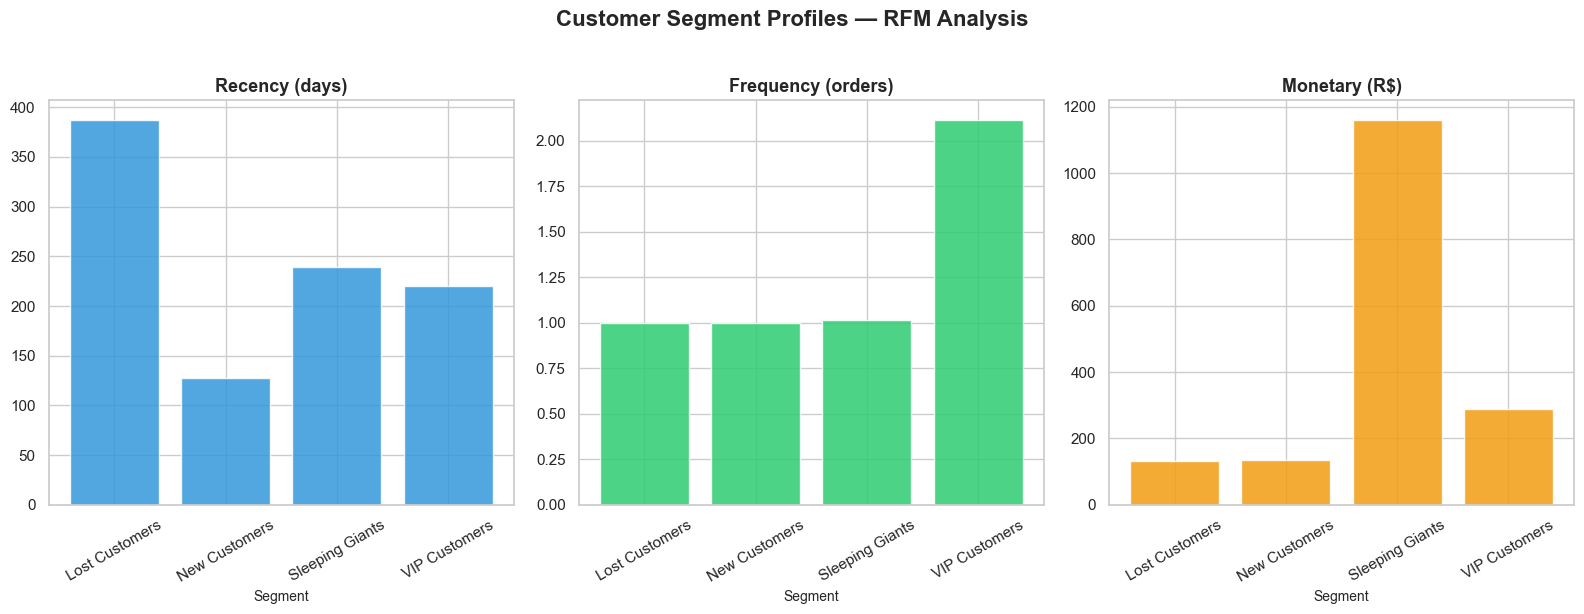

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metrics = ['recency', 'frequency', 'monetary']
titles = ['Recency (days)', 'Frequency (orders)', 'Monetary (R$)']
colors = ['#3498db', '#2ecc71', '#f39c12']

for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    axes[i].bar(segment_profile['segment'],
                segment_profile[metric],
                color=color, alpha=0.85, edgecolor='white')
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Segment', fontsize=10)
    axes[i].tick_params(axis='x', rotation=30)

fig.suptitle('Customer Segment Profiles — RFM Analysis',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../charts/chart13_segment_profiles.png', 
            dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Key Insights — RFM Customer Segmentation

Using RFM analysis and KMeans clustering (K=4), we identified four distinct 
customer segments across 93,358 Olist customers.

The analysis reveals a critical retention problem — 94% of customers are 
one-time buyers, split between New Customers (54%) who haven't returned yet 
and Lost Customers (40%) who have completely disengaged.

Only 3% of customers reached VIP status with repeat purchases, while 
Sleeping Giants — just 2,418 customers — represent the most valuable 
reactivation opportunity, having spent an average of R$1,160 per customer 
despite going quiet for over 239 days.

**The core finding is clear: Olist's growth challenge is not acquisition — 
it is retention. Converting even 10% of Lost Customers back into active 
buyers could generate millions in recovered revenue.**